In [1]:
import fitsio, re
from numpy.typing import NDArray, DTypeLike
from typing import Any

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy

import euclidlib as el

from cloelike import likelihood_3x2

/Users/pedro/miniconda3/envs/cloelite/lib/python3.9/site-packages/HMcode2020Emu
Loading linear emulator...
Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.


In [2]:
# Get n(z)

z_nz, nz_heracles = el.photo.redshift_distributions('test_data/nz_example_heracles.fits')

# Normalise dndz
dndz_pos_norm = deepcopy(nz_heracles)
for key in nz_heracles.keys():
    dndz_pos_norm[key] = nz_heracles[key] / integrate.trapezoid(
                        nz_heracles[key], z_nz)

dndz_she_norm = deepcopy(nz_heracles)
for key in nz_heracles.keys():
    dndz_she_norm[key] = nz_heracles[key] / integrate.trapezoid(
                        nz_heracles[key], z_nz)


# Resampling the normalized n(z) with 100 values
my_dndz_pos = np.vstack(list(dndz_pos_norm.values()))
myz = np.linspace(1e-4, 3., 100)
my_dndz_pos_norm = np.zeros([len(nz_heracles.keys()), 100])
for i in range(6):
    my_dndz_pos_norm[i,:] = np.interp(myz, z_nz, my_dndz_pos[i,:])

my_dndz_she = np.vstack(list(dndz_she_norm.values()))
myz = np.linspace(1e-4, 3., 100)
my_dndz_she_norm = np.zeros([len(nz_heracles.keys()), 100])
for i in range(6):
    my_dndz_she_norm[i,:] = np.interp(myz, z_nz, my_dndz_she[i,:])

In [3]:
##### SHOULD ALL BE DONE WITH EUCLID LIB (sorry Guada)

fits = fitsio.FITS('test_data/cls.fits')

cells_data={}
for hdu in fits[1:]:
    data_temp = hdu.read()
    ell_cell = data_temp['ELL']
    name = hdu.get_extname().split('-')
    cells_data[name[0],name[1],int(name[2])-1,int(name[3])-1]=np.asarray(data_temp['ARRAY'],dtype=float)

######################################################################
#######    DANGER: WE NEED TO UNDERSTAND WHY THIS IS NEEDED    #######
######################################################################
for key in cells_data.keys():
    if key[:2]==('POS','SHE'):
        cells_data[key]=-cells_data[key]



fits_mixmat = fitsio.FITS('test_data/example-mixmats-final-v2.fits')

mixmat={}
for hdu in fits_mixmat[1:]:
    data_temp = hdu.read()
    ell_mixmat = data_temp['ELL']
    name = hdu.get_extname().split('-')
    mixmat[name[0],name[1],int(name[2])-1,int(name[3])-1]=np.asarray(data_temp['ARRAY'],dtype=float)



In [4]:
# Made up Gaussian Covariance without any mixing matrix or anything
loaded_cov=np.load('test_data/cov_Gauss_3x2pt_2D_probe_zpair_ell_2500deg2.npy')

# Expand it to include B mode, but then we have to mask it, otherwise won't work
full_cov = np.zeros((32*(3*21+36),32*(3*21+36)))
full_cov[:32*21,:32*21]=loaded_cov[:32*21,:32*21]
full_cov[32*21:2*32*21,:32*21]=loaded_cov[:32*21,:32*21]
full_cov[:32*21,32*21:2*32*21]=loaded_cov[:32*21,:32*21]
full_cov[-2496:, -2496:]=loaded_cov
full_cov[:32*21,-1824:]=loaded_cov[:32*21,32*21:]
full_cov[-1824:,:32*21]=loaded_cov[32*21:,:32*21]

In [5]:
# Scale cuts have the same format as the data
scale_cut_dict = dict.fromkeys(cells_data.keys(), [10,1500])

for key in cells_data.keys():
    if key[:2]==('SHE','SHE'):
        scale_cut_dict[key]=[scale_cut_dict[key],[0,0]]

In [6]:
data_dict = {'cells':cells_data,'ells':ell_cell,
             'z_arr':myz,'dndz_pos':my_dndz_pos_norm,'dndz_she':my_dndz_she_norm,
             'cov':full_cov,'mixmat':mixmat}

settings_dict = {'n_ell_bins':32,'scale_cuts':scale_cut_dict}

like_test = likelihood_3x2.EuclidLikelihood3x2(data_dict,settings_dict)

In [7]:
%time -2*like_test.loglike({'H0':70,'Omega_cdm0':0.25,'Omega_b0':0.05,'ns':0.965,'As':2.1e-9})/(np.sum(like_test.mask_all)-5)

CPU times: user 7.96 s, sys: 1.53 s, total: 9.5 s
Wall time: 3.5 s


0.03468003387090387

In [8]:
%%time

Oc_arr = np.linspace(0.2,0.3,100)
like_arr=[]
for Oc in Oc_arr:
    like_arr.append(like_test.loglike({'H0':70,'Omega_cdm0':Oc,'Omega_b0':0.05,'ns':0.965,'As':2.1e-9}))

like_arr =np.asarray(like_arr)

CPU times: user 3min 29s, sys: 37.1 s, total: 4min 6s
Wall time: 34.3 s


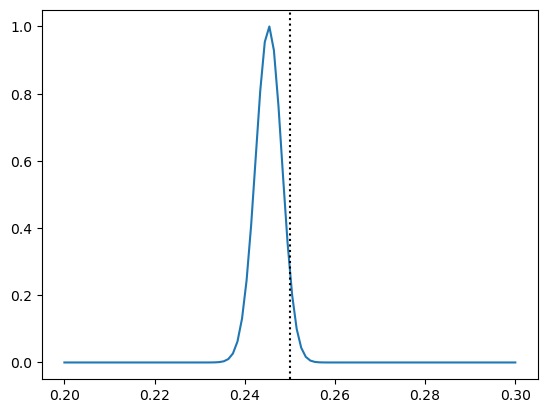

In [9]:
plt.plot(Oc_arr,np.exp(like_arr-np.max(like_arr)))
plt.axvline(0.25,ls=':',c='k')